# Clustering in Scanpy

In [2]:
# Import custom utility packages, lists and functions
from init_env import *
from anndata_utils import *
from gene_lists import *
%load_ext memory_profiler

# Set variables
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5]
batch_col = 'plate' # Should we set to plate and sample??

In [3]:
# Load
adata = load_and_dwnsmpl_data(None, scanpy_dir + 'adata_qc_plate1.h5ad', scanpy_dir + 'adata_qc_plate2.h5ad')

Processing 2 plate(s), no downsampling applied.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate1.h5ad ...
Plate 1 dimensions: (3143, 30522)
Plate 1 matrix dimensions: (3143, 30522)
Loading plate 2 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate2.h5ad ...
Plate 2 dimensions: (3492, 33183)
Plate 2 matrix dimensions: (3492, 33183)
Common genes across all plates: 29459
Merging plates ...
AnnData object with n_obs × n_vars = 6635 × 29459
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden', 'plate', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_

In [ ]:
# Normalise

In [4]:
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                   
plate1_81_12_36__s11  17175    hg38         839        1132         2299   
plate1_45_32_86__s6   17053    hg38        2045        3301         5736   
plate1_48_52_73__s9   12570    hg38        1431        2531         5136   
plate1_30_06_76__s13  17923    hg38        1357        2066         3982   
plate1_61_69_42__s13  12152    hg38        6186       19658        37707   
...                     ...     ...         ...         ...          ...   
plate2_14_67_57__s6    1118    hg38        7726       28085        78260   
plate2_14_73_91__s6    1118    hg38        6727       23733        65906   
plate2_23_59_78__s15  13885    hg38        1645        2480         6162   
plate2_75_33_30__s1   16393    hg38        2947        6259        15805   
plate2_01_45_56__s10  13901    hg38         701         969         2156   

                     leiden   plate  n_genes_by_counts  \
bc_wells                                                 
plate1_81_12_36__s11      0  plate1                839   
plate1_45_32_86__s6       2  plate1               2045   
plate1_48_52_73__s9       4  plate1               1431   
plate1_30_06_76__s13     13  plate1               1357   
plate1_61_69_42__s13      0  plate1               6186   
...                     ...     ...                ...   
plate2_14_67_57__s6       1  plate2               7726   
plate2_14_73_91__s6       1  plate2               6727   
plate2_23_59_78__s15     25  plate2               1645   
plate2_75_33_30__s1       9  plate2               2947   
plate2_01_45_56__s10     20  plate2                701   

                      log1p_n_genes_by_counts  total_counts  ...  \
bc_wells                                                     ...   
plate1_81_12_36__s11                 6.733402   3633.825989  ...   
plate1_45_32_86__s6                  7.623642   6232.163843  ...   
plate1_48_52_73__s9                  7.266827   4609.112377  ...   
plate1_30_06_76__s13                 7.213768   4630.806848  ...   
plate1_61_69_42__s13                 8.730206   9855.973899  ...   
...                                       ...           ...  ...   
plate2_14_67_57__s6                  8.952476  12587.998325  ...   
plate2_14_73_91__s6                  8.814033  11474.442358  ...   
plate2_23_59_78__s15                 7.406103   5629.076484  ...   
plate2_75_33_30__s1                  7.988882   7288.435908  ...   
plate2_01_45_56__s10                 6.553933   2813.893028  ...   

                      log1p_total_counts_hb  pct_counts_hb  n_genes  \
bc_wells                                                              
plate1_81_12_36__s11               0.000000       0.000000      836   
plate1_45_32_86__s6                0.000000       0.000000     2040   
plate1_48_52_73__s9                0.000000       0.000000     1429   
plate1_30_06_76__s13               0.000000       0.000000     1357   
plate1_61_69_42__s13               0.957232       0.016279     6171   
...                                     ...            ...      ...   
plate2_14_67_57__s6                1.288240       0.020864     7658   
plate2_14_73_91__s6                2.582572       0.106595     6684   
plate2_23_59_78__s15               0.000000       0.000000     1641   
plate2_75_33_30__s1                1.146613       0.029465     2939   
plate2_01_45_56__s10               0.000000       0.000000      701   

                          n_counts  doublet_score  predicted_doublet  \
bc_wells                                                               
plate1_81_12_36__s11   3633.825989       0.031038              False   
plate1_45_32_86__s6    6232.163843       0.051711              False   
plate1_48_52_73__s9    4609.112377       0.095379              False   
plate1_30_06_76__s13   4630.806848       0.051711              False   
plate1_61_69_42__s13   9855.973899  

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
# Get highly variable genes

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
    ... clipping at max_value 10


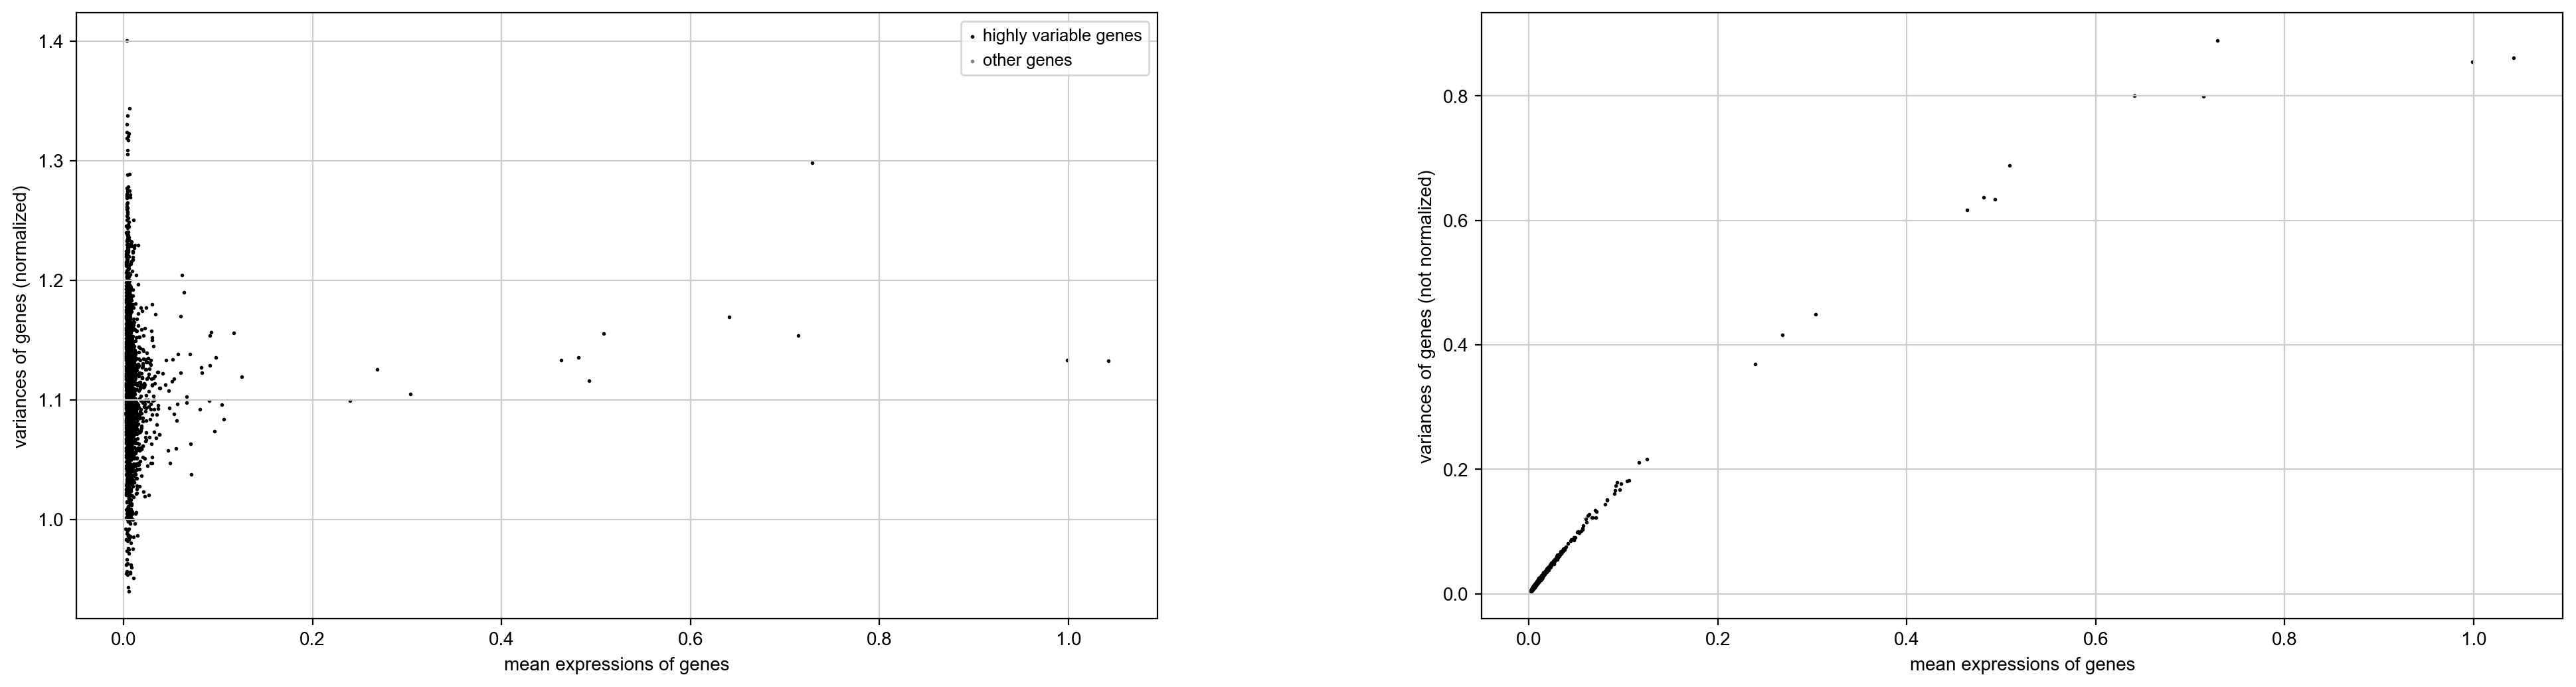

In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='plate')
# This saves the original set of genes 
adata.raw = adata

adata = adata[:,adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.pl.highly_variable_genes(adata)

In [ ]:
# PCA

computing PCA
    with n_comps=50
    finished (0:00:03)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])


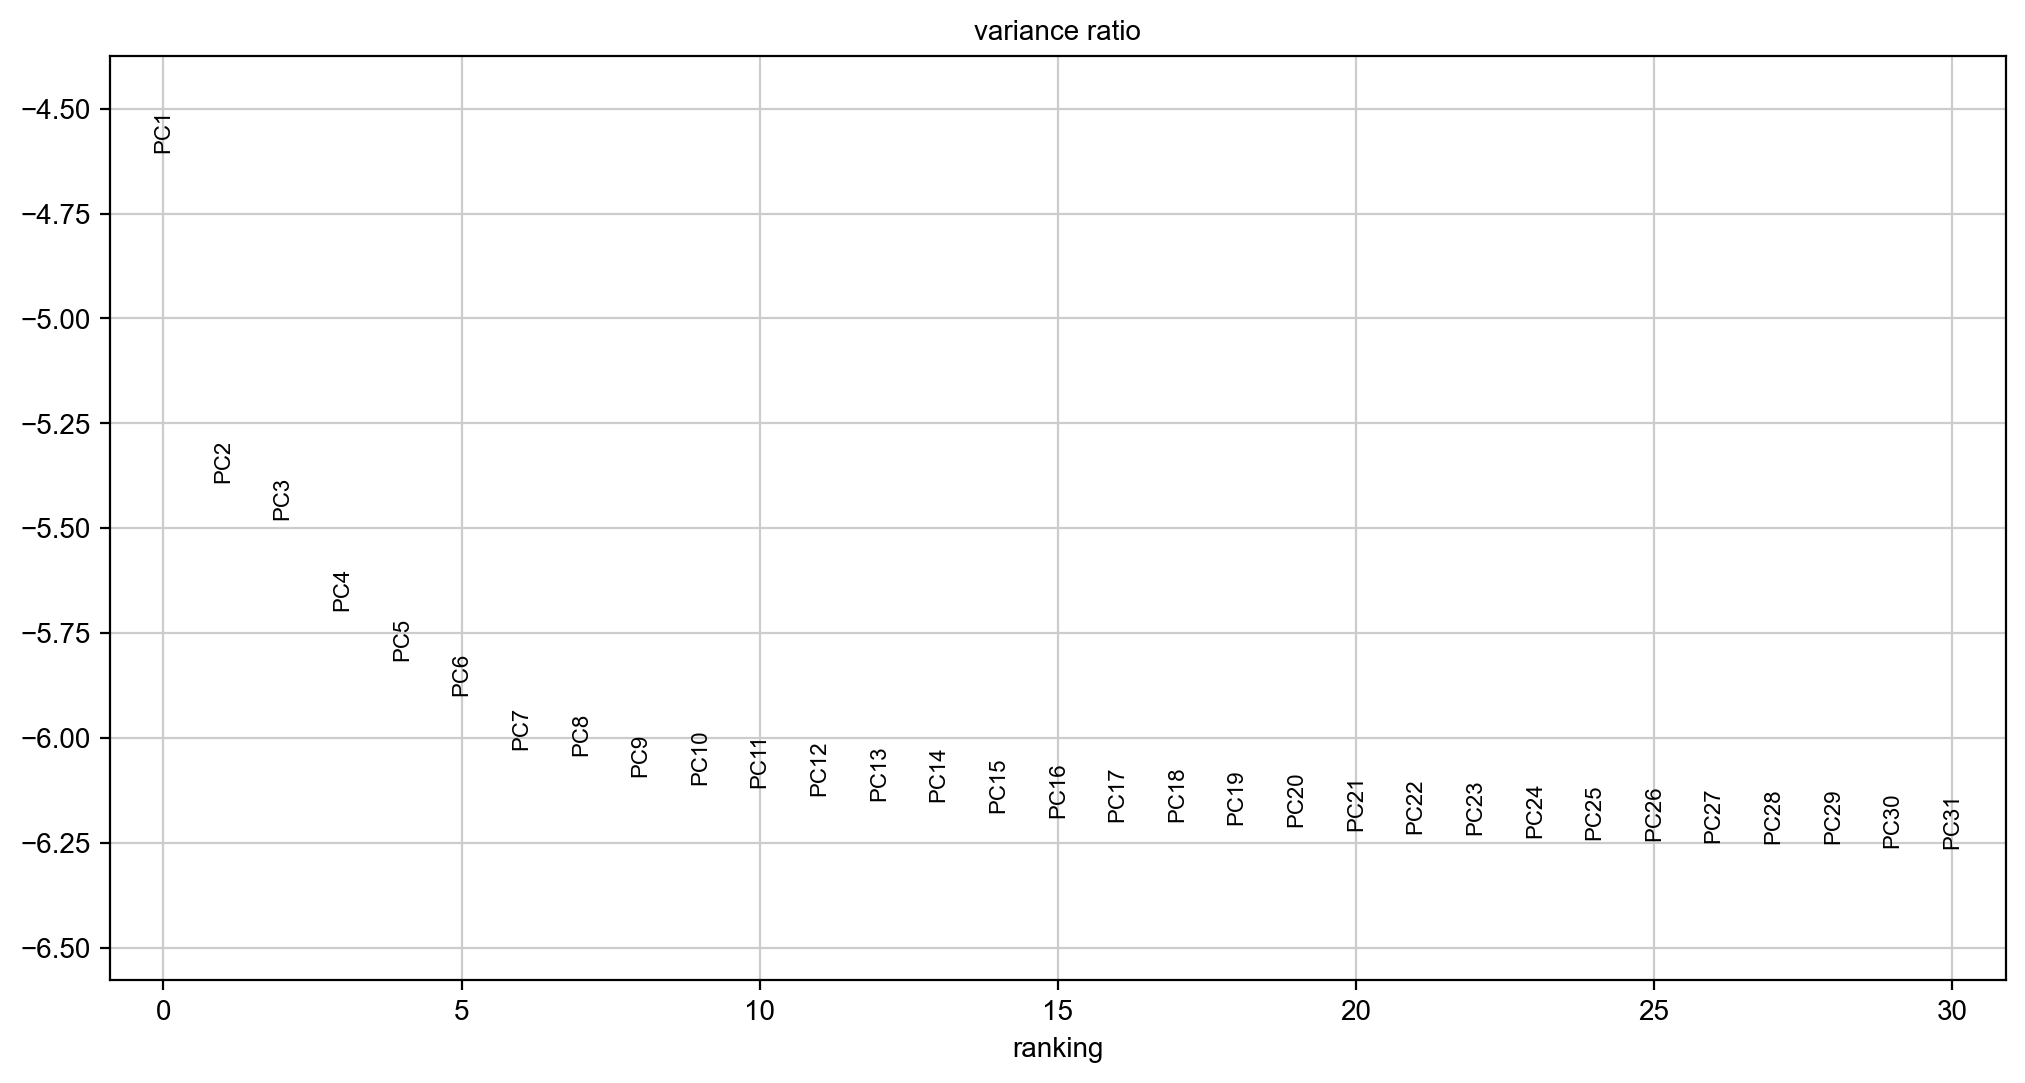

In [7]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30, save='') # scanpy generates the filename automatically

In [ ]:
# UMAP and Clustering

In [8]:
# Plotting
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                   
plate1_81_12_36__s11  17175    hg38         839        1132         2299   
plate1_45_32_86__s6   17053    hg38        2045        3301         5736   
plate1_48_52_73__s9   12570    hg38        1431        2531         5136   
plate1_30_06_76__s13  17923    hg38        1357        2066         3982   
plate1_61_69_42__s13  12152    hg38        6186       19658        37707   
...                     ...     ...         ...         ...          ...   
plate2_14_67_57__s6    1118    hg38        7726       28085        78260   
plate2_14_73_91__s6    1118    hg38        6727       23733        65906   
plate2_23_59_78__s15  13885    hg38        1645        2480         6162   
plate2_75_33_30__s1   16393    hg38        2947        6259        15805   
plate2_01_45_56__s10  13901    hg38         701         969         2156   

                     leiden   plate  n_genes_by_counts  \
bc_wells                                                 
plate1_81_12_36__s11      0  plate1                839   
plate1_45_32_86__s6       2  plate1               2045   
plate1_48_52_73__s9       4  plate1               1431   
plate1_30_06_76__s13     13  plate1               1357   
plate1_61_69_42__s13      0  plate1               6186   
...                     ...     ...                ...   
plate2_14_67_57__s6       1  plate2               7726   
plate2_14_73_91__s6       1  plate2               6727   
plate2_23_59_78__s15     25  plate2               1645   
plate2_75_33_30__s1       9  plate2               2947   
plate2_01_45_56__s10     20  plate2                701   

                      log1p_n_genes_by_counts  total_counts  ...  \
bc_wells                                                     ...   
plate1_81_12_36__s11                 6.733402   3633.825989  ...   
plate1_45_32_86__s6                  7.623642   6232.163843  ...   
plate1_48_52_73__s9                  7.266827   4609.112377  ...   
plate1_30_06_76__s13                 7.213768   4630.806848  ...   
plate1_61_69_42__s13                 8.730206   9855.973899  ...   
...                                       ...           ...  ...   
plate2_14_67_57__s6                  8.952476  12587.998325  ...   
plate2_14_73_91__s6                  8.814033  11474.442358  ...   
plate2_23_59_78__s15                 7.406103   5629.076484  ...   
plate2_75_33_30__s1                  7.988882   7288.435908  ...   
plate2_01_45_56__s10                 6.553933   2813.893028  ...   

                      log1p_total_counts_hb  pct_counts_hb  n_genes  \
bc_wells                                                              
plate1_81_12_36__s11               0.000000       0.000000      836   
plate1_45_32_86__s6                0.000000       0.000000     2040   
plate1_48_52_73__s9                0.000000       0.000000     1429   
plate1_30_06_76__s13               0.000000       0.000000     1357   
plate1_61_69_42__s13               0.957232       0.016279     6171   
...                                     ...            ...      ...   
plate2_14_67_57__s6                1.288240       0.020864     7658   
plate2_14_73_91__s6                2.582572       0.106595     6684   
plate2_23_59_78__s15               0.000000       0.000000     1641   
plate2_75_33_30__s1                1.146613       0.029465     2939   
plate2_01_45_56__s10               0.000000       0.000000      701   

                          n_counts  doublet_score  predicted_doublet  \
bc_wells                                                               
plate1_81_12_36__s11   3633.825989       0.031038              False   
plate1_45_32_86__s6    6232.163843       0.051711              False   
plate1_48_52_73__s9    4609.112377       0.095379              False   
plate1_30_06_76__s13   4630.806848       0.051711              False   
plate1_61_69_42__s13   9855.973899  

In [9]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)

for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 30
    computed neighbors (0:00:00)


/Users/darren/miniconda3/envs/eqtl_study/lib/python3.12/site-packages/scipy/sparse/_index.py:197: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


    computed connectivities (0:00:04)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)
running Leiden clustering
    finished: found 3 clusters and added
    'leiden_0.1', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 13 clusters and added
    'leiden_0.4', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden cluster

In [10]:
# Helper function
create_umap_visualisations(adata, resolutions, leiden_prefix="leiden")

In [20]:
# Violin plots
gene_sets = [
    ("general_genes", general_genes)
]
plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=resolutions, 
    row_palette=discreet_cols_n23
)

Genes not found in dataset for gene set general_genes: PVALB, VIP, PDGRFA
Generating plots for resolution: 0.1
Plotting gene set general_genes with 24 genes out of 27 provided.
Generating plots for resolution: 0.2
Plotting gene set general_genes with 24 genes out of 27 provided.
Generating plots for resolution: 0.3
Plotting gene set general_genes with 24 genes out of 27 provided.
Generating plots for resolution: 0.4
Plotting gene set general_genes with 24 genes out of 27 provided.
Generating plots for resolution: 0.5
Plotting gene set general_genes with 24 genes out of 27 provided.


In [16]:
gene_sets = [
    ("general_genes", general_genes),
    ("pfc_features", pfc_features)
]

plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base='leiden', 
    resolutions=['0.1', '0.5'], 
    row_palette='viridis'
)



Genes not found in dataset for gene set general_genes: PVALB, VIP, PDGRFA
Generating plots for resolution: 0.1
Plotting gene set general_genes with 24 genes out of 27 provided.
Plotting gene set pfc_features with 15 genes out of 15 provided.
Generating plots for resolution: 0.5
Plotting gene set general_genes with 24 genes out of 27 provided.
Plotting gene set pfc_features with 15 genes out of 15 provided.
